# Experiment 8: Effect of PCA on Regression and Classification Models

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, f1_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC

RANDOM_STATE = 42
OUTPUT_DIR = "outputs_exp8"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder created:", OUTPUT_DIR)


Output folder created: outputs_exp8


In [2]:
# Load dataset
df = pd.read_csv("Dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (1000, 13)


,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium



Columns:
['Math', 'Physics', 'Chemistry', 'Biology', 'Total_Science', 'Average_Science', 'English', 'Computer_Science', 'Sports_Score', 'Attendance_Percentage', 'Random_Noise_Feature', 'Final_Score_Regression', 'Performance_Level_Classification']


## 1. Dataset summary and compact EDA

In [3]:
# Identify feature columns and targets
reg_target = "Final_Score_Regression"
clf_target = "Performance_Level_Classification"

feature_cols = [c for c in df.columns if c not in [reg_target, clf_target]]

X = df[feature_cols].copy()
y_reg = df[reg_target].copy()
y_clf_raw = df[clf_target].copy()

print("Number of samples:", df.shape[0])
print("Number of total columns:", df.shape[1])
print("Number of input features:", len(feature_cols))
print("\nFeature columns:")
for col in feature_cols:
    print("-", col)


Number of samples: 1000
Number of total columns: 13
Number of input features: 11

Feature columns:
- Math
- Physics
- Chemistry
- Biology
- Total_Science
- Average_Science
- English
- Computer_Science
- Sports_Score
- Attendance_Percentage
- Random_Noise_Feature


In [4]:
# Missing values report
missing_report = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
display(missing_report.to_frame("missing_count"))


Missing values per column:


,missing_count
Math,0
Physics,0
Chemistry,0
Biology,0
Total_Science,0
Average_Science,0
English,0
Computer_Science,0
Sports_Score,0
Attendance_Percentage,0


Regression target summary:


,count,mean,std,min,25%,50%,75%,max
Final_Score_Regression,1000.0,66.621902,10.243337,37.230851,59.931376,66.712433,73.707292,111.586769


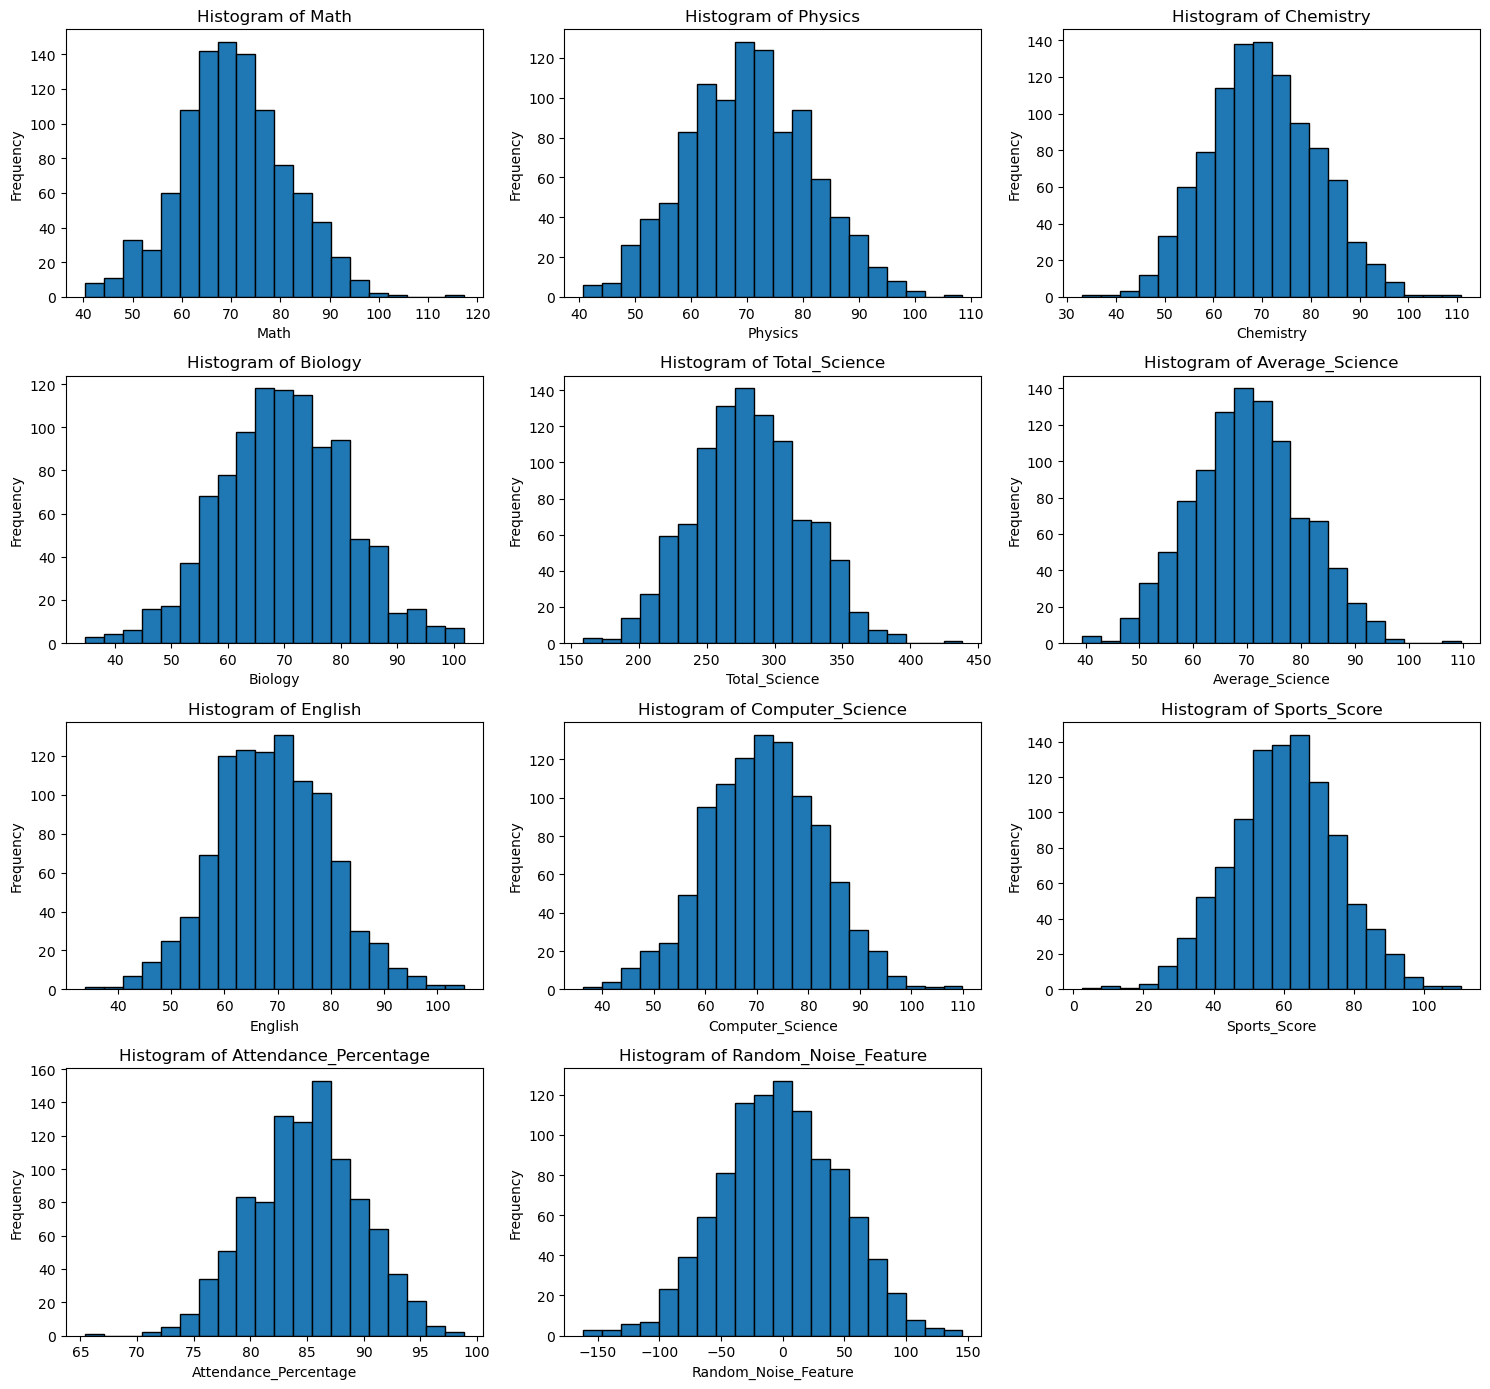

<Figure size 640x480 with 0 Axes>

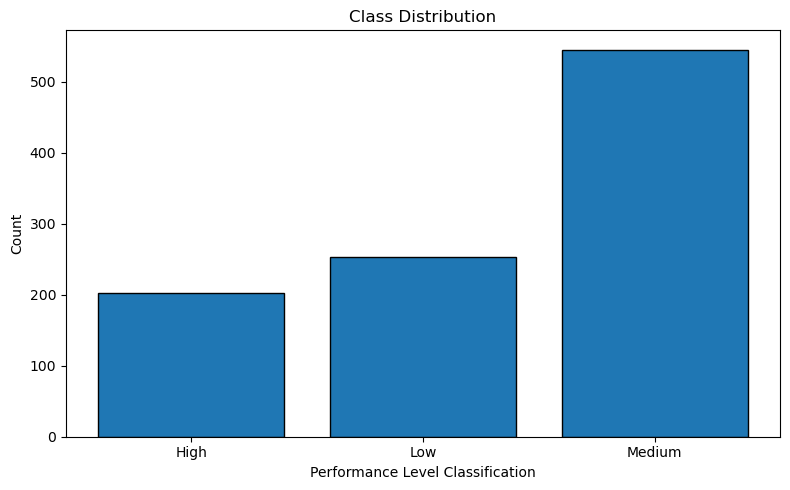

Classification target distribution:


,count
Performance_Level_Classification,
High,202
Low,253
Medium,545


<Figure size 640x480 with 0 Axes>

In [19]:
# Compact EDA: feature distribution histograms + class distribution bar graph

print("Regression target summary:")
display(y_reg.describe().to_frame().T)

# Feature distribution histograms
num_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(num_features / n_cols))

plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))
for i, col in enumerate(feature_cols, start=1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col].dropna(), bins=20, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
plt.savefig("feature_histograms.eps", format='eps', dpi=600)
plt.savefig("feature_pdf.pdf", bbox_inches='tight')
# Class distribution bar graph
clf_distribution = y_clf_raw.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(clf_distribution.index.astype(str), clf_distribution.values, edgecolor="black")
plt.title("Class Distribution")
plt.xlabel("Performance Level Classification")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("class_dist.eps", format='eps', dpi=600)
plt.savefig("class_pdf.pdf", bbox_inches='tight')
print("Classification target distribution:")
display(clf_distribution.to_frame("count"))


In [6]:
# Encode classification target
label_encoder = LabelEncoder()
y_clf = label_encoder.fit_transform(y_clf_raw)

mapping_df = pd.DataFrame({
    "Class Label": label_encoder.classes_,
    "Encoded Value": range(len(label_encoder.classes_))
})
print("Classification label encoding:")
display(mapping_df)


Classification label encoding:


,Class Label,Encoded Value
0,High,0
1,Low,1
2,Medium,2


## 2. PCA summary and scree plot


In [7]:
# Standardize full feature matrix for PCA analysis only
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# Full PCA to inspect explained variance by component
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var_ratio)

# PCA retaining 95% variance
pca_95 = PCA(n_components=0.95)
pca_95.fit(X_scaled)

n_components_95 = pca_95.n_components_
explained_95 = cum_explained[n_components_95 - 1] * 100

pca_summary = pd.DataFrame({
    "Components Chosen": [n_components_95],
    "Explained Variance (%)": [round(explained_95, 4)],
    "Justification": ["Retain at least 95% cumulative explained variance"]
})

display(pca_summary)


,Components Chosen,Explained Variance (%),Justification
0,7,95.8952,Retain at least 95% cumulative explained variance


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


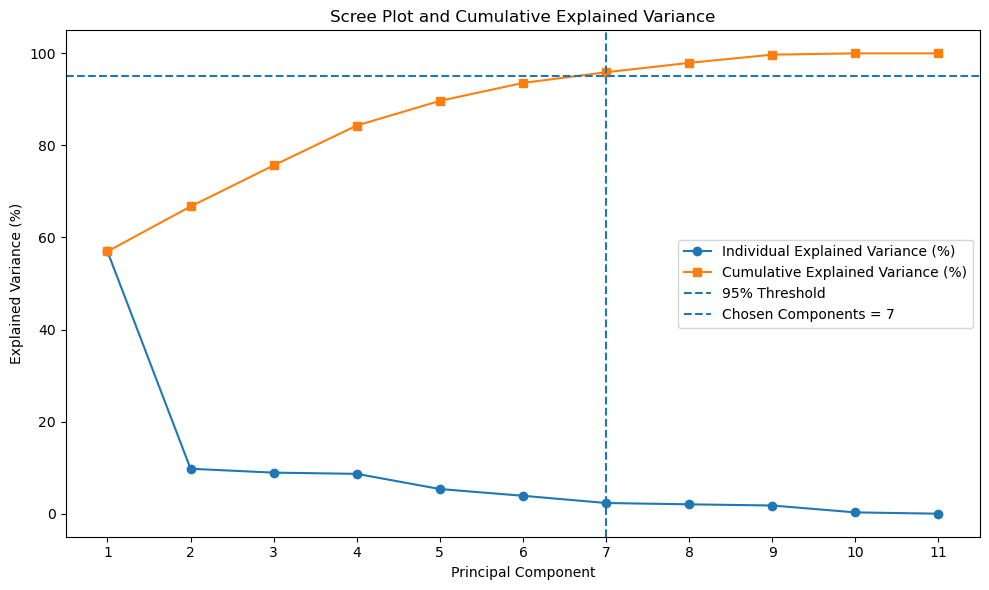

Saved: outputs_exp8\exp8_scree_plot.eps


In [8]:
# Scree plot + cumulative explained variance
component_numbers = np.arange(1, len(explained_var_ratio) + 1)

plt.figure(figsize=(10, 6))
plt.plot(component_numbers, explained_var_ratio * 100, marker='o', label='Individual Explained Variance (%)')
plt.plot(component_numbers, cum_explained * 100, marker='s', label='Cumulative Explained Variance (%)')
plt.axhline(y=95, linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, linestyle='--', label=f'Chosen Components = {n_components_95}')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot and Cumulative Explained Variance")
plt.xticks(component_numbers)
plt.legend()
plt.tight_layout()

scree_path = os.path.join(OUTPUT_DIR, "exp8_scree_plot.eps")
plt.savefig(scree_path, format="eps", dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", scree_path)


## 3. Helper functions for 5-fold CV comparison

In [9]:
def evaluate_regression_model_cv(X_df, y, model_name, model_no_pca, model_with_pca, 
                                 param_grid_no_pca=None, param_grid_with_pca=None,
                                 outer_splits=5, inner_splits=3, random_state=42):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)

    fold_results = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_df, y), start=1):
        X_train = X_df.iloc[train_idx]
        X_test = X_df.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ----- No PCA -----
        if param_grid_no_pca is not None:
            inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
            grid_no_pca = GridSearchCV(
                estimator=model_no_pca,
                param_grid=param_grid_no_pca,
                scoring="neg_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            grid_no_pca.fit(X_train, y_train)
            best_no_pca = grid_no_pca.best_estimator_
        else:
            best_no_pca = model_no_pca.fit(X_train, y_train)

        y_pred_no_pca = best_no_pca.predict(X_test)
        mse_no_pca = mean_squared_error(y_test, y_pred_no_pca)
        r2_no_pca = r2_score(y_test, y_pred_no_pca)

        # ----- With PCA -----
        if param_grid_with_pca is not None:
            inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
            grid_with_pca = GridSearchCV(
                estimator=model_with_pca,
                param_grid=param_grid_with_pca,
                scoring="neg_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            grid_with_pca.fit(X_train, y_train)
            best_with_pca = grid_with_pca.best_estimator_
        else:
            best_with_pca = model_with_pca.fit(X_train, y_train)

        y_pred_with_pca = best_with_pca.predict(X_test)
        mse_with_pca = mean_squared_error(y_test, y_pred_with_pca)
        r2_with_pca = r2_score(y_test, y_pred_with_pca)

        fold_results.append({
            "Fold": fold_idx,
            "Model": model_name,
            "MSE_No_PCA": mse_no_pca,
            "R2_No_PCA": r2_no_pca,
            "MSE_With_PCA": mse_with_pca,
            "R2_With_PCA": r2_with_pca
        })

    return pd.DataFrame(fold_results)


def evaluate_classification_model_cv(X_df, y, model_name, model_no_pca, model_with_pca,
                                     param_grid_no_pca=None, param_grid_with_pca=None,
                                     outer_splits=5, inner_splits=3, random_state=42):
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)

    fold_results = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_df, y), start=1):
        X_train = X_df.iloc[train_idx]
        X_test = X_df.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        # ----- No PCA -----
        if param_grid_no_pca is not None:
            inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
            grid_no_pca = GridSearchCV(
                estimator=model_no_pca,
                param_grid=param_grid_no_pca,
                scoring="f1_weighted",
                cv=inner_cv,
                n_jobs=-1
            )
            grid_no_pca.fit(X_train, y_train)
            best_no_pca = grid_no_pca.best_estimator_
        else:
            best_no_pca = model_no_pca.fit(X_train, y_train)

        y_pred_no_pca = best_no_pca.predict(X_test)
        acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
        f1_no_pca = f1_score(y_test, y_pred_no_pca, average="weighted")

        # ----- With PCA -----
        if param_grid_with_pca is not None:
            inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
            grid_with_pca = GridSearchCV(
                estimator=model_with_pca,
                param_grid=param_grid_with_pca,
                scoring="f1_weighted",
                cv=inner_cv,
                n_jobs=-1
            )
            grid_with_pca.fit(X_train, y_train)
            best_with_pca = grid_with_pca.best_estimator_
        else:
            best_with_pca = model_with_pca.fit(X_train, y_train)

        y_pred_with_pca = best_with_pca.predict(X_test)
        acc_with_pca = accuracy_score(y_test, y_pred_with_pca)
        f1_with_pca = f1_score(y_test, y_pred_with_pca, average="weighted")

        fold_results.append({
            "Fold": fold_idx,
            "Model": model_name,
            "Accuracy_No_PCA": acc_no_pca,
            "F1_No_PCA": f1_no_pca,
            "Accuracy_With_PCA": acc_with_pca,
            "F1_With_PCA": f1_with_pca
        })

    return pd.DataFrame(fold_results)


## 4. Build pipelines and tune required models

In [10]:
# -------------------------
# REGRESSION PIPELINES
# -------------------------

# Linear Regression (No PCA)
linreg_no_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Linear Regression (With PCA)
linreg_with_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LinearRegression())
])

# Random Forest Regressor (No PCA)
rfreg_no_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

# Random Forest Regressor (With PCA)
rfreg_with_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

rfreg_param_grid_no_pca = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

rfreg_param_grid_with_pca = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

# -------------------------
# CLASSIFICATION PIPELINES
# -------------------------

# Logistic Regression (No PCA)
logreg_no_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

# Logistic Regression (With PCA)
logreg_with_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

logreg_param_grid_no_pca = {
    "model__C": [0.01, 0.1, 1, 10]
}

logreg_param_grid_with_pca = {
    "model__C": [0.01, 0.1, 1, 10]
}

# SVM (No PCA)
svm_no_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=RANDOM_STATE))
])

# SVM (With PCA)
svm_with_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", SVC(random_state=RANDOM_STATE))
])

svm_param_grid_no_pca = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}

svm_param_grid_with_pca = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}

print("Pipelines ready.")


Pipelines ready.


## 5. Regression: 5-fold CV comparison

In [11]:
linreg_results = evaluate_regression_model_cv(
    X_df=X,
    y=y_reg,
    model_name="Linear Regression",
    model_no_pca=linreg_no_pca,
    model_with_pca=linreg_with_pca,
    param_grid_no_pca=None,
    param_grid_with_pca=None,
    outer_splits=5,
    inner_splits=3,
    random_state=RANDOM_STATE
)

rfreg_results = evaluate_regression_model_cv(
    X_df=X,
    y=y_reg,
    model_name="Random Forest Regressor",
    model_no_pca=rfreg_no_pca,
    model_with_pca=rfreg_with_pca,
    param_grid_no_pca=rfreg_param_grid_no_pca,
    param_grid_with_pca=rfreg_param_grid_with_pca,
    outer_splits=5,
    inner_splits=3,
    random_state=RANDOM_STATE
)

display(linreg_results)
display(rfreg_results)


,Fold,Model,MSE_No_PCA,R2_No_PCA,MSE_With_PCA,R2_With_PCA
0,1,Linear Regression,28.398330,0.755366,28.856982,0.751415
1,2,Linear Regression,23.266827,0.759034,23.143903,0.760307
2,3,Linear Regression,28.160165,0.716920,28.145869,0.717064
3,4,Linear Regression,26.460508,0.745676,26.617821,0.744164
4,5,Linear Regression,24.883371,0.762480,24.618486,0.765008


,Fold,Model,MSE_No_PCA,R2_No_PCA,MSE_With_PCA,R2_With_PCA
0,1,Random Forest Regressor,32.735004,0.718008,32.485694,0.720156
1,2,Random Forest Regressor,25.663373,0.734213,25.824078,0.732549
2,3,Random Forest Regressor,29.075608,0.707717,30.192598,0.696489
3,4,Random Forest Regressor,29.039292,0.720890,29.407827,0.717348
4,5,Random Forest Regressor,26.568253,0.746397,27.057460,0.741728


In [12]:
# Build Table 2: 5-Fold CV Results – Regression
regression_summary = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Metric": "MSE",
        "Fold Avg (No PCA)": linreg_results["MSE_No_PCA"].mean(),
        "Fold Avg (With PCA)": linreg_results["MSE_With_PCA"].mean(),
    },
    {
        "Model": "Linear Regression",
        "Metric": "R2",
        "Fold Avg (No PCA)": linreg_results["R2_No_PCA"].mean(),
        "Fold Avg (With PCA)": linreg_results["R2_With_PCA"].mean(),
    },
    {
        "Model": "Random Forest Regressor",
        "Metric": "MSE",
        "Fold Avg (No PCA)": rfreg_results["MSE_No_PCA"].mean(),
        "Fold Avg (With PCA)": rfreg_results["MSE_With_PCA"].mean(),
    },
    {
        "Model": "Random Forest Regressor",
        "Metric": "R2",
        "Fold Avg (No PCA)": rfreg_results["R2_No_PCA"].mean(),
        "Fold Avg (With PCA)": rfreg_results["R2_With_PCA"].mean(),
    }
])

regression_summary_rounded = regression_summary.copy()
for col in ["Fold Avg (No PCA)", "Fold Avg (With PCA)"]:
    regression_summary_rounded[col] = regression_summary_rounded[col].round(5)

display(regression_summary_rounded)


,Model,Metric,Fold Avg (No PCA),Fold Avg (With PCA)
0,Linear Regression,MSE,26.23384,26.27661
1,Linear Regression,R2,0.74789,0.74759
2,Random Forest Regressor,MSE,28.61631,28.99353
3,Random Forest Regressor,R2,0.72545,0.72165


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


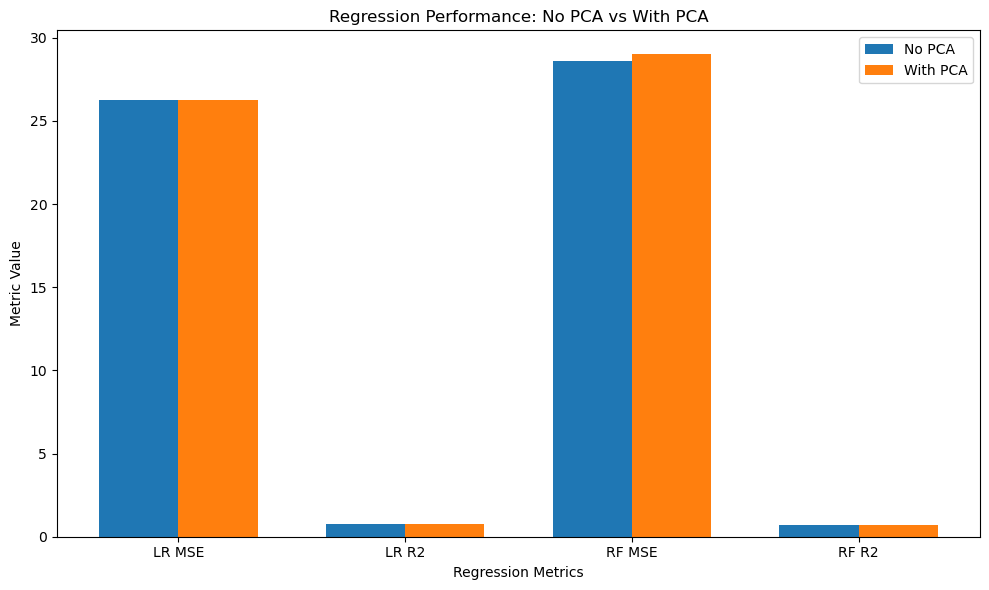

Saved: outputs_exp8\exp8_regression_comparison.eps


In [13]:
# Regression comparison plot
labels = ["LR MSE", "LR R2", "RF MSE", "RF R2"]
no_pca_vals = [
    linreg_results["MSE_No_PCA"].mean(),
    linreg_results["R2_No_PCA"].mean(),
    rfreg_results["MSE_No_PCA"].mean(),
    rfreg_results["R2_No_PCA"].mean()
]
with_pca_vals = [
    linreg_results["MSE_With_PCA"].mean(),
    linreg_results["R2_With_PCA"].mean(),
    rfreg_results["MSE_With_PCA"].mean(),
    rfreg_results["R2_With_PCA"].mean()
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, no_pca_vals, width, label="No PCA")
plt.bar(x + width/2, with_pca_vals, width, label="With PCA")
plt.xticks(x, labels)
plt.ylabel("Metric Value")
plt.xlabel("Regression Metrics")
plt.title("Regression Performance: No PCA vs With PCA")
plt.legend()
plt.tight_layout()

reg_plot_path = os.path.join(OUTPUT_DIR, "exp8_regression_comparison.eps")
plt.savefig(reg_plot_path, format="eps", dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", reg_plot_path)


## 6. Classification: 5-fold CV comparison

In [14]:
logreg_results = evaluate_classification_model_cv(
    X_df=X,
    y=y_clf,
    model_name="Logistic Regression",
    model_no_pca=logreg_no_pca,
    model_with_pca=logreg_with_pca,
    param_grid_no_pca=logreg_param_grid_no_pca,
    param_grid_with_pca=logreg_param_grid_with_pca,
    outer_splits=5,
    inner_splits=3,
    random_state=RANDOM_STATE
)

svm_results = evaluate_classification_model_cv(
    X_df=X,
    y=y_clf,
    model_name="SVM",
    model_no_pca=svm_no_pca,
    model_with_pca=svm_with_pca,
    param_grid_no_pca=svm_param_grid_no_pca,
    param_grid_with_pca=svm_param_grid_with_pca,
    outer_splits=5,
    inner_splits=3,
    random_state=RANDOM_STATE
)

display(logreg_results)
display(svm_results)


,Fold,Model,Accuracy_No_PCA,F1_No_PCA,Accuracy_With_PCA,F1_With_PCA
0,1,Logistic Regression,0.765,0.762551,0.770,0.768522
1,2,Logistic Regression,0.775,0.772114,0.765,0.759961
2,3,Logistic Regression,0.755,0.752535,0.760,0.758553
3,4,Logistic Regression,0.765,0.760356,0.750,0.747060
4,5,Logistic Regression,0.685,0.683698,0.675,0.674320


,Fold,Model,Accuracy_No_PCA,F1_No_PCA,Accuracy_With_PCA,F1_With_PCA
0,1,SVM,0.775,0.772315,0.795,0.792817
1,2,SVM,0.760,0.755984,0.765,0.760600
2,3,SVM,0.770,0.766368,0.765,0.762222
3,4,SVM,0.745,0.739113,0.750,0.747060
4,5,SVM,0.690,0.688752,0.680,0.679015


In [15]:
# Build Table 3: 5-Fold CV Results – Classification
classification_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Metric": "Accuracy",
        "Fold Avg (No PCA)": logreg_results["Accuracy_No_PCA"].mean(),
        "Fold Avg (With PCA)": logreg_results["Accuracy_With_PCA"].mean(),
        "Observation": "Higher is better"
    },
    {
        "Model": "Logistic Regression",
        "Metric": "F1-score",
        "Fold Avg (No PCA)": logreg_results["F1_No_PCA"].mean(),
        "Fold Avg (With PCA)": logreg_results["F1_With_PCA"].mean(),
        "Observation": "Higher is better"
    },
    {
        "Model": "SVM",
        "Metric": "Accuracy",
        "Fold Avg (No PCA)": svm_results["Accuracy_No_PCA"].mean(),
        "Fold Avg (With PCA)": svm_results["Accuracy_With_PCA"].mean(),
        "Observation": "Higher is better"
    },
    {
        "Model": "SVM",
        "Metric": "F1-score",
        "Fold Avg (No PCA)": svm_results["F1_No_PCA"].mean(),
        "Fold Avg (With PCA)": svm_results["F1_With_PCA"].mean(),
        "Observation": "Higher is better"
    }
])

classification_summary_rounded = classification_summary.copy()
for col in ["Fold Avg (No PCA)", "Fold Avg (With PCA)"]:
    classification_summary_rounded[col] = classification_summary_rounded[col].round(5)

display(classification_summary_rounded)


,Model,Metric,Fold Avg (No PCA),Fold Avg (With PCA),Observation
0,Logistic Regression,Accuracy,0.74900,0.74400,Higher is better
1,Logistic Regression,F1-score,0.74625,0.74168,Higher is better
2,SVM,Accuracy,0.74800,0.75100,Higher is better
3,SVM,F1-score,0.74451,0.74834,Higher is better


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


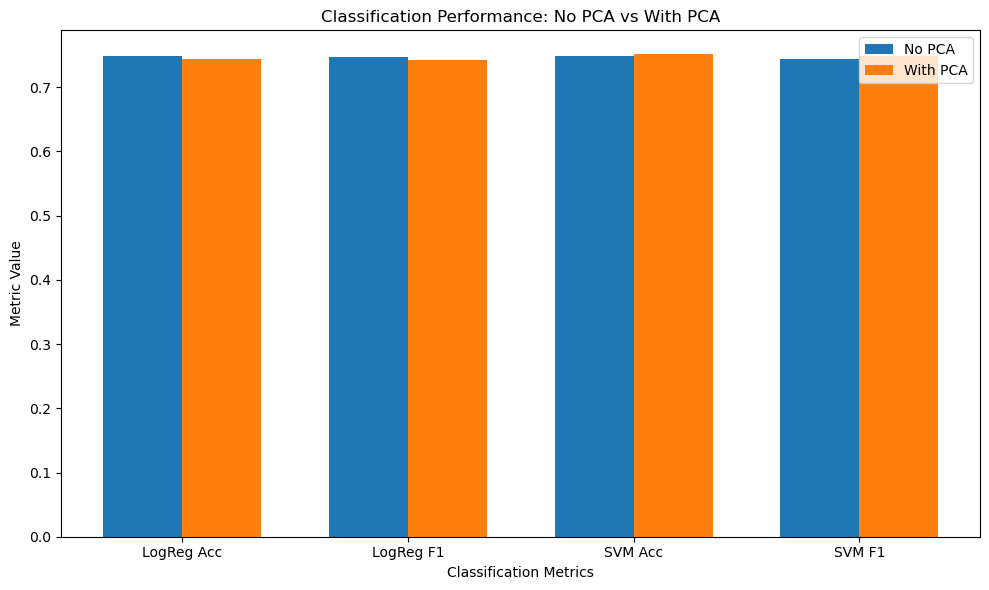

Saved: outputs_exp8\exp8_classification_comparison.eps


In [16]:
# Classification comparison plot
labels = ["LogReg Acc", "LogReg F1", "SVM Acc", "SVM F1"]
no_pca_vals = [
    logreg_results["Accuracy_No_PCA"].mean(),
    logreg_results["F1_No_PCA"].mean(),
    svm_results["Accuracy_No_PCA"].mean(),
    svm_results["F1_No_PCA"].mean()
]
with_pca_vals = [
    logreg_results["Accuracy_With_PCA"].mean(),
    logreg_results["F1_With_PCA"].mean(),
    svm_results["Accuracy_With_PCA"].mean(),
    svm_results["F1_With_PCA"].mean()
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, no_pca_vals, width, label="No PCA")
plt.bar(x + width/2, with_pca_vals, width, label="With PCA")
plt.xticks(x, labels)
plt.ylabel("Metric Value")
plt.xlabel("Classification Metrics")
plt.title("Classification Performance: No PCA vs With PCA")
plt.legend()
plt.tight_layout()

clf_plot_path = os.path.join(OUTPUT_DIR, "exp8_classification_comparison.eps")
plt.savefig(clf_plot_path, format="eps", dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", clf_plot_path)


## 7. Variance across folds


In [17]:
variance_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Metric": "MSE",
        "Std Dev (No PCA)": linreg_results["MSE_No_PCA"].std(),
        "Std Dev (With PCA)": linreg_results["MSE_With_PCA"].std()
    },
    {
        "Model": "Linear Regression",
        "Metric": "R2",
        "Std Dev (No PCA)": linreg_results["R2_No_PCA"].std(),
        "Std Dev (With PCA)": linreg_results["R2_With_PCA"].std()
    },
    {
        "Model": "Random Forest Regressor",
        "Metric": "MSE",
        "Std Dev (No PCA)": rfreg_results["MSE_No_PCA"].std(),
        "Std Dev (With PCA)": rfreg_results["MSE_With_PCA"].std()
    },
    {
        "Model": "Random Forest Regressor",
        "Metric": "R2",
        "Std Dev (No PCA)": rfreg_results["R2_No_PCA"].std(),
        "Std Dev (With PCA)": rfreg_results["R2_With_PCA"].std()
    },
    {
        "Model": "Logistic Regression",
        "Metric": "Accuracy",
        "Std Dev (No PCA)": logreg_results["Accuracy_No_PCA"].std(),
        "Std Dev (With PCA)": logreg_results["Accuracy_With_PCA"].std()
    },
    {
        "Model": "Logistic Regression",
        "Metric": "F1-score",
        "Std Dev (No PCA)": logreg_results["F1_No_PCA"].std(),
        "Std Dev (With PCA)": logreg_results["F1_With_PCA"].std()
    },
    {
        "Model": "SVM",
        "Metric": "Accuracy",
        "Std Dev (No PCA)": svm_results["Accuracy_No_PCA"].std(),
        "Std Dev (With PCA)": svm_results["Accuracy_With_PCA"].std()
    },
    {
        "Model": "SVM",
        "Metric": "F1-score",
        "Std Dev (No PCA)": svm_results["F1_No_PCA"].std(),
        "Std Dev (With PCA)": svm_results["F1_With_PCA"].std()
    }
])

display(variance_table.round(5))


,Model,Metric,Std Dev (No PCA),Std Dev (With PCA)
0,Linear Regression,MSE,2.18369,2.38915
1,Linear Regression,R2,0.01842,0.01886
2,Random Forest Regressor,MSE,2.75081,2.62671
3,Random Forest Regressor,R2,0.01505,0.01714
4,Logistic Regression,Accuracy,0.03647,0.03927
5,Logistic Regression,F1-score,0.03566,0.03842
6,SVM,Accuracy,0.03439,0.04292
7,SVM,F1-score,0.03362,0.04222
